# Disaster effects prediction and insight with NSF

**steps**:
- load the disaster dataset and feats dataset
- combine them
- make a dataset for each disaster type
- for each type (starting with only one):
    * standardize and normalize the features
    * define the NSF model
    * train the model
    * inspect the resulting distribution
    * see the conditioning features effects

**dataset design**:
- one dataframe per event type
- time reference feat as ...
- no topographical feat as coords, not state/county
- geographical and natural feats for conditioning
- casualties and damages as y 

#### imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import matplotlib.colors as mcolors

import seaborn as sns
from pathlib import Path
from scipy.stats import gaussian_kde
from scipy import stats
import time

import torch
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import zuko

import utils

In [2]:
DATASET_PATH = Path("../datasets/disasters_merged_all_feats.csv")
EVENT_GROUP = 'Hail'
RUN_PATH = Path(f"../runs/best_flow_{EVENT_GROUP.lower()}.pt")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## Data Preparation

In [3]:
df = pd.read_csv(DATASET_PATH)

### Group by event type

In [4]:
df['EVENT_GROUP'].value_counts()

EVENT_GROUP
Wind           152966
Hail            57980
Storm           55795
Flood           49691
Freeze          39347
Drought         20115
Snow            19792
Heat            14279
Heavy Rain      10488
Fog              4943
Wildfire         2505
Lightning        2261
Debris Flow      1047
Avalanche         203
Name: count, dtype: int64

In [5]:
event_group_dfs = {
    'Hail': df[df['EVENT_GROUP'] == 'Hail'].drop(columns=['EVENT_GROUP', 'WIND_SPEED']),
    'Wind': df[df['EVENT_GROUP'] == 'Wind'].drop(columns=['EVENT_GROUP', 'HAIL_SIZE']),
    'Storm': df[df['EVENT_GROUP'] == 'Storm'].drop(columns=['EVENT_GROUP', 'HAIL_SIZE']),
    'Flood': df[df['EVENT_GROUP'] == 'Flood'].drop(columns=['EVENT_GROUP', 'HAIL_SIZE']),
    'Freeze': df[df['EVENT_GROUP'] == 'Freeze'].drop(columns=['EVENT_GROUP', 'HAIL_SIZE']),
    'Drought': df[df['EVENT_GROUP'] == 'Drought'].drop(columns=['EVENT_GROUP', 'HAIL_SIZE']),
    'Snow': df[df['EVENT_GROUP'] == 'Snow'].drop(columns=['EVENT_GROUP', 'HAIL_SIZE']),
    'Heat': df[df['EVENT_GROUP'] == 'Heat'].drop(columns=['EVENT_GROUP', 'HAIL_SIZE']),
    'Heavy Rain': df[df['EVENT_GROUP'] == 'Heavy Rain'].drop(columns=['EVENT_GROUP', 'HAIL_SIZE']),
    'Fog': df[df['EVENT_GROUP'] == 'Fog'].drop(columns=['EVENT_GROUP', 'HAIL_SIZE']),
    'Wildfire': df[df['EVENT_GROUP'] == 'Wildfire'].drop(columns=['EVENT_GROUP', 'HAIL_SIZE']),
    'Lightning': df[df['EVENT_GROUP'] == 'Lightning'].drop(columns=['EVENT_GROUP', 'HAIL_SIZE']),
    'Debris Flow': df[df['EVENT_GROUP'] == 'Debris Flow'].drop(columns=['EVENT_GROUP', 'HAIL_SIZE']),
    'Avalanche': df[df['EVENT_GROUP'] == 'Avalanche'].drop(columns=['EVENT_GROUP', 'HAIL_SIZE']),
}

In [6]:
event_group_dfs['Hail'].head()

,DAMAGES,CASUALTIES,DURATION_HOURS,HAIL_SIZE,TIME_DAY_SIN,TIME_DAY_COS,TIME_YEAR_NORM,PRECIPITATION,TMIN,TMAX,...,SLOPE,COV_BARREN,COV_CULTIVATED,COV_VEGETATION,COV_FOREST,COV_WATER,COV_SNOW_ICE,COV_URBAN,RIVER_DISTANCE,SEA_DISTANCE
65,0.0,0,0.0,1.00,0.154204,0.988039,0.0,1404.65,11.66,22.69,...,1.89,0.000,0.716,0.146,0.136,0.002,0.0,0.000,256.4,415.3
72,0.0,0,0.0,0.88,0.353445,0.935455,0.0,1519.92,12.85,24.73,...,6.01,0.003,0.120,0.047,0.769,0.040,0.0,0.021,1082.0,170.3
74,0.0,0,0.0,1.00,0.353445,0.935455,0.0,1478.56,12.41,24.58,...,5.17,0.000,0.328,0.094,0.538,0.001,0.0,0.040,515.2,217.7
76,100.0,0,0.0,1.75,0.353445,0.935455,0.0,1589.20,12.37,24.92,...,7.35,0.000,0.049,0.020,0.930,0.001,0.0,0.000,925.4,142.4
82,0.0,0,0.0,1.00,0.353445,0.935455,0.0,1437.68,12.31,24.38,...,4.94,0.000,0.183,0.119,0.467,0.018,0.0,0.212,377.5,223.6


In [7]:
df = event_group_dfs[EVENT_GROUP]

### Data normalization

In [8]:
TARGET_COLS = ["DAMAGES", "CASUALTIES"]

X_COLS = [
    'BEGIN_LAT', 'BEGIN_LON',
    'DURATION_HOURS', 'HAIL_SIZE', # change with hail size for hail
    'TIME_DAY_SIN', 'TIME_DAY_COS', 'TIME_YEAR_NORM',
    'PRECIPITATION', 'TMIN', 'TMAX',
    'ELEVATION', 'SLOPE',
    'COV_BARREN', 'COV_CULTIVATED', 'COV_VEGETATION',
    'COV_FOREST', 'COV_WATER', 'COV_SNOW_ICE', 'COV_URBAN',
    'RIVER_DISTANCE', 'SEA_DISTANCE',
]

In [9]:
X = df[X_COLS].values.astype(np.float32)
Y = df[TARGET_COLS].values.astype(np.float32)

In [10]:
# targets log transformation
Y = np.log1p(Y)

In [11]:
# train-val-test split
X_train, X_temp, Y_train, Y_temp = train_test_split(X, Y, test_size=0.3, random_state=42)

X_val, X_test, Y_val, Y_test = train_test_split(X_temp, Y_temp, test_size=0.5, random_state=42)

In [12]:
# standardize features and targets
x_scaler = StandardScaler()
y_scaler = StandardScaler()

X_train = x_scaler.fit_transform(X_train)
X_val   = x_scaler.transform(X_val)
X_test  = x_scaler.transform(X_test)

Y_train = y_scaler.fit_transform(Y_train)
Y_val   = y_scaler.transform(Y_val)
Y_test  = y_scaler.transform(Y_test)


### Dataset split

In [13]:
# conversion to tensors and move to device
X_train = torch.tensor(X_train).to(device)
Y_train = torch.tensor(Y_train).to(device)

X_val = torch.tensor(X_val).to(device)
Y_val = torch.tensor(Y_val).to(device)

X_test = torch.tensor(X_test).to(device)
Y_test = torch.tensor(Y_test).to(device)


In [14]:
# data loaders
train_ds = TensorDataset(X_train, Y_train)
val_ds   = TensorDataset(X_val, Y_val)
test_ds   = TensorDataset(X_val, Y_val)

## Model

In [15]:
df = event_group_dfs[EVENT_GROUP]

### Data normalization and Dataset creation

In [16]:
TARGET_COLS = ["DAMAGES", "CASUALTIES"]

X_COLS = [
    'BEGIN_LAT', 'BEGIN_LON',
    'DURATION_HOURS', 'HAIL_SIZE',
    'TIME_DAY_SIN', 'TIME_DAY_COS', 'TIME_YEAR_NORM',
    'PRECIPITATION', 'TMIN', 'TMAX',
    'ELEVATION', 'SLOPE',
    'COV_BARREN', 'COV_CULTIVATED', 'COV_VEGETATION',
    'COV_FOREST', 'COV_WATER', 'COV_SNOW_ICE', 'COV_URBAN',
    'RIVER_DISTANCE', 'SEA_DISTANCE'
]

In [17]:
X = df[X_COLS].values.astype(np.float32)
Y = df[TARGET_COLS].values.astype(np.float32)

In [18]:
# targets log transformation
Y = np.log1p(Y)

In [19]:
# train-val-test split
X_train, X_temp, Y_train, Y_temp = train_test_split(
    X, Y, test_size=0.3, random_state=42
)

X_val, X_test, Y_val, Y_test = train_test_split(
    X_temp, Y_temp, test_size=0.5, random_state=42
)

In [20]:
# standardize features and targets
x_scaler = StandardScaler()
y_scaler = StandardScaler()

X_train = x_scaler.fit_transform(X_train)
X_val   = x_scaler.transform(X_val)
X_test  = x_scaler.transform(X_test)

Y_train = y_scaler.fit_transform(Y_train)
Y_val   = y_scaler.transform(Y_val)
Y_test  = y_scaler.transform(Y_test)


In [21]:
# conversion to tensors
X_train = torch.tensor(X_train)
Y_train = torch.tensor(Y_train)

X_val = torch.tensor(X_val)
Y_val = torch.tensor(Y_val)

X_test = torch.tensor(X_test)
Y_test = torch.tensor(Y_test)

In [22]:
# data loaders
train_ds = TensorDataset(X_train, Y_train)
val_ds   = TensorDataset(X_val, Y_val)
test_ds   = TensorDataset(X_val, Y_val)

### Model definition

In [23]:
EPOCHS = 200
LEARNING_RATE = 1e-3
BATCH_SIZE = 256

In [24]:
X_DIM = X_train.shape[1]
Y_DIM = 2   # DAMAGES, CASUALTIES

flow = zuko.flows.NSF(
    features=Y_DIM,
    context=X_DIM,
    transforms=8,
    hidden_features=[256, 256, 256],
    bins=16
)

In [25]:
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE)
test_loader   = DataLoader(test_ds, batch_size=BATCH_SIZE)

In [26]:
print(f"NSF model created with {sum(p.numel() for p in flow.parameters())} parameters")

NSF model created with 1295088 parameters


### Model Loading

In [27]:
flow.load_state_dict(torch.load(RUN_PATH))
flow.eval()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
flow = flow.to(device)

C:\Users\matti\AppData\Local\Temp\ipykernel_27604\4212689827.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  flow.load_state_dict(torch.load(RUN_PATH))


### Model Evaluation

In [28]:
def sample_predictive(flow, x, n=10000):
    """
    x: torch tensor shape (1, X_DIM)
    returns samples in original scale: (n,2)
    """
    with torch.no_grad():
        dist = flow(x)
        samples = dist.sample((n,)).squeeze(1).cpu().numpy()

    samples = y_scaler.inverse_transform(samples)
    samples = np.expm1(samples)
    return samples


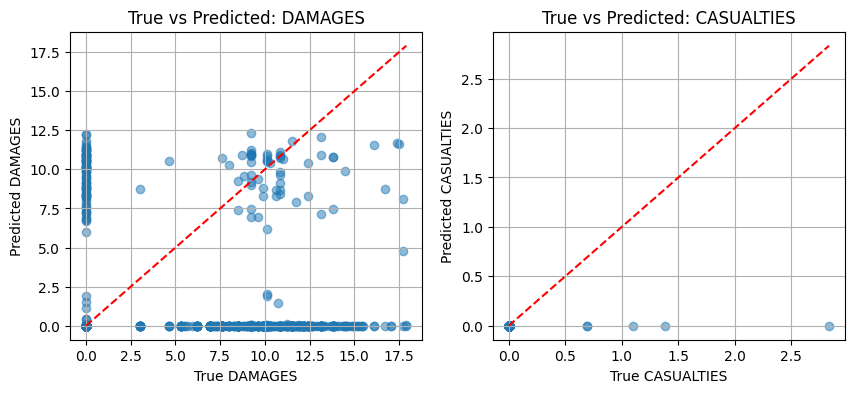

In [29]:
# Run inference for the test set and plot results for damages and casualties
def run_inference_and_plot(flow, test_loader, y_scaler, target_cols):
    flow.eval()
    y_true = []
    y_pred = []
    with torch.no_grad():
        for x_batch, y_batch in test_loader:
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)
            # Get the distribution and sample from it
            dist = flow(x_batch)
            y_hat = dist.sample().squeeze(1)  # shape: [batch, 2]
            y_true.append(y_batch.cpu())
            y_pred.append(y_hat.cpu())
    y_true = torch.cat(y_true, dim=0).numpy()
    y_pred = torch.cat(y_pred, dim=0).numpy()
    # Inverse scale
    y_true = y_scaler.inverse_transform(y_true)
    y_pred = y_scaler.inverse_transform(y_pred)
    # Plot for each target
    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1)
    plt.scatter(y_true[:, 0], y_pred[:, 0], alpha=0.5)
    plt.xlabel(f"True {target_cols[0]}")
    plt.ylabel(f"Predicted {target_cols[0]}")
    plt.title(f"True vs Predicted: {target_cols[0]}")
    plt.plot([y_true[:, 0].min(), y_true[:, 0].max()], [y_true[:, 0].min(), y_true[:, 0].max()], 'r--')
    plt.grid()
    plt.subplot(1,2,2)
    plt.scatter(y_true[:, 1], y_pred[:, 1], alpha=0.5)
    plt.xlabel(f"True {target_cols[1]}")
    plt.ylabel(f"Predicted {target_cols[1]}")
    plt.title(f"True vs Predicted: {target_cols[1]}")
    plt.plot([y_true[:, 1].min(), y_true[:, 1].max()], [y_true[:, 1].min(), y_true[:, 1].max()], 'r--')
    plt.grid()
    plt.show()

run_inference_and_plot(flow, test_loader, y_scaler, TARGET_COLS)

Average predicted std for DAMAGES: 0.3013
Average predicted std for CASUALTIES: 0.0000
MSE for DAMAGES: 5.2534
MSE for CASUALTIES: 0.0014


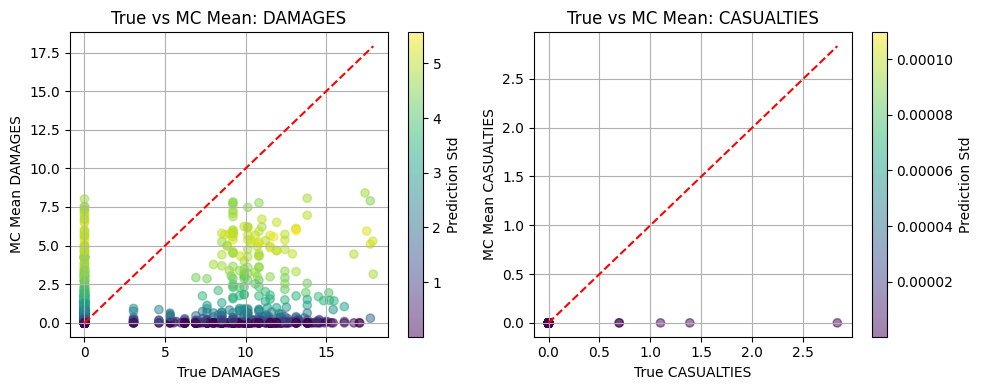

In [30]:
def run_inference_and_plot_mc(flow, test_loader, y_scaler, target_cols, n_samples=3):
    """Run Monte Carlo inference by sampling multiple times from the conditional distribution.
    
    For each (x, y) in the test set:
    - Sample n_samples times from p(y|x)
    - Compute mean and std of samples
    - Compare mean prediction to true y
    """
    flow.eval()
    y_true_all = []
    y_mean_all = []
    y_std_all = []
    
    with torch.no_grad():
        for x_batch, y_batch in test_loader:
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)
            B = x_batch.shape[0]
            
            # Get the conditional distribution
            dist = flow(x_batch)
            
            # Sample multiple times: [n_samples, B, 2]
            samples = torch.stack([dist.sample().squeeze(1) for _ in range(n_samples)], dim=0)
            
            # Move to CPU and convert to numpy: [n_samples, B, 2]
            samples_np = samples.cpu().numpy()
            
            # Inverse scale all samples
            n_s, B, D = samples_np.shape
            samples_flat = samples_np.reshape(n_s * B, D)
            samples_unscaled = y_scaler.inverse_transform(samples_flat).reshape(n_s, B, D)
            
            # Compute mean and std over samples dimension (axis=0)
            means = samples_unscaled.mean(axis=0)  # [B, 2]
            stds = samples_unscaled.std(axis=0)    # [B, 2]
            
            # Inverse scale true values
            y_true_unscaled = y_scaler.inverse_transform(y_batch.cpu().numpy())
            
            y_true_all.append(y_true_unscaled)
            y_mean_all.append(means)
            y_std_all.append(stds)
    
    y_true_all = np.concatenate(y_true_all, axis=0)
    y_mean_all = np.concatenate(y_mean_all, axis=0)
    y_std_all = np.concatenate(y_std_all, axis=0)
    
    # Report overall average std per target
    avg_std = y_std_all.mean(axis=0)
    print(f"Average predicted std for {target_cols[0]}: {avg_std[0]:.4f}")
    print(f"Average predicted std for {target_cols[1]}: {avg_std[1]:.4f}")
    
    # Compute MSE
    mse_0 = np.mean((y_true_all[:, 0] - y_mean_all[:, 0]) ** 2)
    mse_1 = np.mean((y_true_all[:, 1] - y_mean_all[:, 1]) ** 2)
    print(f"MSE for {target_cols[0]}: {mse_0:.4f}")
    print(f"MSE for {target_cols[1]}: {mse_1:.4f}")
    
    # Plot for each target
    plt.figure(figsize=(10, 4))
    
    # Target 0
    plt.subplot(1, 2, 1)
    plt.scatter(y_true_all[:, 0], y_mean_all[:, 0], alpha=0.5,
                c=y_std_all[:, 0], cmap='viridis')
    plt.colorbar(label='Prediction Std')
    plt.xlabel(f"True {target_cols[0]}")
    plt.ylabel(f"MC Mean {target_cols[0]}")
    plt.title(f"True vs MC Mean: {target_cols[0]}")
    plt.plot(
        [y_true_all[:, 0].min(), y_true_all[:, 0].max()],
        [y_true_all[:, 0].min(), y_true_all[:, 0].max()],
        'r--'
    )
    plt.grid()
    
    # Target 1
    plt.subplot(1, 2, 2)
    plt.scatter(y_true_all[:, 1], y_mean_all[:, 1], alpha=0.5,
                c=y_std_all[:, 1], cmap='viridis')
    plt.colorbar(label='Prediction Std')
    plt.xlabel(f"True {target_cols[1]}")
    plt.ylabel(f"MC Mean {target_cols[1]}")
    plt.title(f"True vs MC Mean: {target_cols[1]}")
    plt.plot(
        [y_true_all[:, 1].min(), y_true_all[:, 1].max()],
        [y_true_all[:, 1].min(), y_true_all[:, 1].max()],
        'r--'
    )
    plt.grid()
    
    plt.tight_layout()
    plt.show()
    
    return y_true_all, y_mean_all, y_std_all

# Run Monte Carlo inference
y_true, y_mean, y_std = run_inference_and_plot_mc(
    flow, test_loader, y_scaler, TARGET_COLS, n_samples=100
)

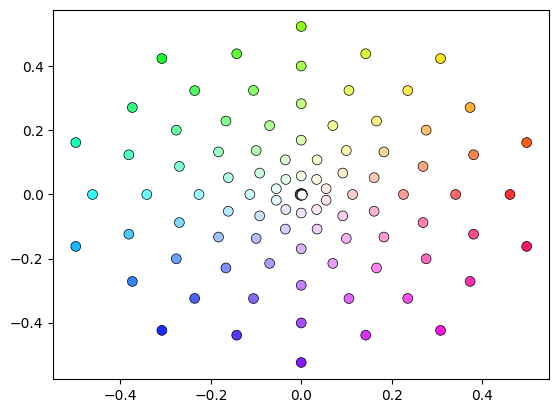

In [31]:
def get_gaussian_lattice(device='cpu', n_rings=10, n_points=10):
    """
    Generates a fixed 101-point lattice for 2D flow visualization.
    
    Structure:
    - 1 Center point (0,0)
    - n Rings of k points each
    - Radii based on Gaussian probability intervals
    - Alternating phase shift (0, 2pi/k) between rings
    
    Returns:
        z (Tensor): [1+n*k, 2] inputs for the flow inverse.
        colors (Array): [1+n*k, 3] RGB values for plotting the output.
    """

    import torch
    import matplotlib.colors as mcolors

    points = []
    colors_hsv = []

    # --- 1. The Center (Point 0) ---
    points.append([0.0, 0.0])
    # Color: White (Saturation=0, Value=1)
    colors_hsv.append([0.0, 0.0, 1.0]) 

    # --- 2. The 10 Rings ---
    phase_shift = np.pi / n_points  # Alternating shift
    
    # Calculate radii corresponding to equidistant Gaussian probabilities
    # We slice probability space from 51% to 95%
    # This ensures we cover the 'meat' of the distribution and the tails
    probs = torch.linspace(0.501, 0.7, n_rings)
    dist = torch.distributions.Normal(0, 1)
    radii = dist.icdf(probs) # Transform prob -> gaussian radius (sigma)
    max_r = radii[-1].item()

    for i, r in enumerate(radii):
        r = r.item()
        
        # Alternating phase: Even rings start at 0, Odd rings start at pi/20
        # (i starts at 0, so ring 1 is index 0)
        current_phase = phase_shift if (i % 2 != 0) else 0.0
        
        # Generate 10 angles for this ring
        angles = torch.linspace(0, 2*np.pi, n_points + 1)[:-1] + current_phase
        
        # Polar -> Cartesian
        x = r * torch.cos(angles)
        y = r * torch.sin(angles)
        
        # Append points
        ring_points = torch.stack([x, y], dim=1)
        points.append(ring_points)
        
        # --- Color Logic (Polar -> HSV) ---
        # Hue = Angle (normalized 0-1)
        # Saturation = Radius (normalized 0-1)
        # Value = 1.0 (Max brightness)
        
        # Normalize angles to [0, 1] for Hue
        # We use modulo to strictly keep it in range
        hues = (angles % (2*np.pi)) / (2*np.pi)
        
        # Saturation increases with radius (White center -> Vivid edge)
        saturation = r / (max_r * 1.1) # Divide by slightly more than max to avoid clipping
        saturations = torch.full_like(hues, saturation)
        
        values = torch.ones_like(hues) # Full brightness
        
        # Stack HSV for this ring
        ring_hsv = torch.stack([hues, saturations, values], dim=1)
        colors_hsv.append(ring_hsv)

    # --- 3. Assemble Final Tensors ---
    # Concatenate all lists into single tensors
    z_tensor = torch.cat([torch.tensor(points[:1]), torch.cat(points[1:])], dim=0)
    c_tensor_hsv = torch.cat([torch.tensor(colors_hsv[:1]), torch.cat(colors_hsv[1:])], dim=0)
    
    # SAFETY: Clamp HSV values to [0, 1] to prevent matplotlib errors
    c_tensor_hsv = torch.clamp(c_tensor_hsv, 0, 1)
    colors_rgb = mcolors.hsv_to_rgb(c_tensor_hsv.cpu().numpy())
    
    return z_tensor.float().to(device), colors_rgb
# 1. Get the lattice
z_fixed, point_colors = get_gaussian_lattice(device='cpu', n_rings=10, n_points=10)

# 3. Visualize
plt.scatter(z_fixed[:, 0], z_fixed[:, 1], c=point_colors, s=50, edgecolors='k', linewidth=0.5)
plt.show()

In [32]:
def run_inference_sample(flow, test_loader, y_scaler, target_cols):
    """Run inference using a fixed Gaussian lattice in latent space.

    For each (x, y) in the test set, we:
    - Map all lattice points `z_fixed` through the inverse flow conditioned on x
    - Obtain many samples in y-space, then compute their mean and std per target
    - Collect these means as predictions and compare to true y, like in `run_inference_and_plot`.
    """
    flow.eval()

    y_true_all = []   # inverse-scaled ground truth
    y_mean_all = []   # inverse-scaled lattice means
    y_std_all = []    # inverse-scaled lattice stds

    # Move lattice to device once
    z = z_fixed.to(device)  # shape: [N, 2]
    N = z.shape[0]

    with torch.no_grad():
        for x_batch, y_batch in test_loader:
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)
            B = x_batch.shape[0]

            # We need to create B copies of the lattice and B copies of x
            # Then flatten to pass through the inverse transform
            
            # Expand x to match each lattice point: [B, N, x_dim] -> [B*N, x_dim]
            x_expanded = x_batch.unsqueeze(1).expand(-1, N, -1).reshape(B * N, -1)
            
            # Expand z to match each batch element: [N, 2] -> [B, N, 2] -> [B*N, 2]
            z_expanded = z.unsqueeze(0).expand(B, -1, -1).reshape(B * N, -1)
            
            # Get conditional distribution for expanded x
            dist = flow(x_expanded)  # conditional distribution p(y|x) for all B*N pairs
            
            # Invert the flow from lattice points in latent space to y-space
            y_samples = dist.transform.inv(z_expanded)  # [B*N, 2]
            
            # Reshape back to [B, N, 2]
            y_samples = y_samples.reshape(B, N, -1)

            # Inverse-scale all samples to original target space
            B, N, D = y_samples.shape
            y_samples_np = y_samples.reshape(B * N, D).cpu().numpy()
            y_samples_unscaled = y_scaler.inverse_transform(y_samples_np).reshape(B, N, D)

            # Mean and std over lattice dimension N for each sample in batch
            means = y_samples_unscaled.mean(axis=1)  # [B, 2]
            stds = y_samples_unscaled.std(axis=1)    # [B, 2]

            y_true_unscaled = y_scaler.inverse_transform(y_batch.cpu().numpy())

            y_true_all.append(y_true_unscaled)
            y_mean_all.append(means)
            y_std_all.append(stds)

    y_true_all = np.concatenate(y_true_all, axis=0)
    y_mean_all = np.concatenate(y_mean_all, axis=0)
    y_std_all = np.concatenate(y_std_all, axis=0)

    # Report overall average std per target
    avg_std = y_std_all.mean(axis=0)
    print(f"Average predicted std for {target_cols[0]} and {target_cols[1]}:", avg_std)

    # Scatter true vs lattice-mean predictions (like original function)
    plt.figure(figsize=(10, 4))

    # Target 0
    plt.subplot(1, 2, 1)
    plt.scatter(y_true_all[:, 0], y_mean_all[:, 0], alpha=0.5)
    plt.xlabel(f"True {target_cols[0]}")
    plt.ylabel(f"Lattice mean {target_cols[0]}")
    plt.title(f"True vs Lattice Mean: {target_cols[0]}")
    plt.plot(
        [y_true_all[:, 0].min(), y_true_all[:, 0].max()],
        [y_true_all[:, 0].min(), y_true_all[:, 0].max()],
        'r--'
    )
    plt.grid()

    # Target 1
    plt.subplot(1, 2, 2)
    plt.scatter(y_true_all[:, 1], y_mean_all[:, 1], alpha=0.5)
    plt.xlabel(f"True {target_cols[1]}")
    plt.ylabel(f"Lattice mean {target_cols[1]}")
    plt.title(f"True vs Lattice Mean: {target_cols[1]}")
    plt.plot(
        [y_true_all[:, 1].min(), y_true_all[:, 1].max()],
        [y_true_all[:, 1].min(), y_true_all[:, 1].max()],
        'r--'
    )
    plt.grid()

    plt.tight_layout()
    plt.show()

Average predicted std for DAMAGES and CASUALTIES: [4.5272678e-02 9.4821907e-08]


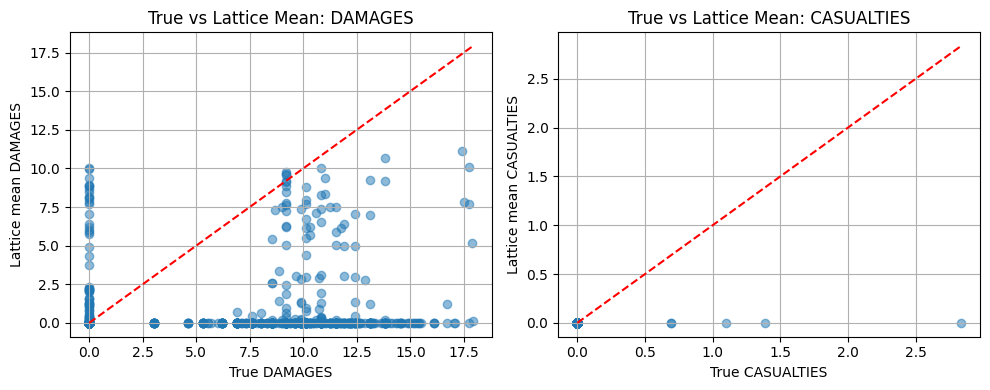

In [33]:
from utils import get_gaussian_lattice

run_inference_sample(flow, test_loader, y_scaler, TARGET_COLS)


In [34]:
def run_inference_map(flow, test_loader, y_scaler, target_cols, 
                      n_iterations=100, lr=0.01, n_init_points=10):
    """Run inference by finding MAP (maximum a posteriori) estimates in latent space.

    For each (x, y) in the test set, we:
    - Initialize multiple points in latent space
    - Use gradient ascent to maximize log p(z|x) for each initialization
    - Take the best (highest probability) point from all initializations
    - Invert through the flow once to get the MAP estimate in y-space
    - Compare to true y
    """
    flow.eval()

    y_true_all = []   # inverse-scaled ground truth
    y_map_all = []    # inverse-scaled MAP estimates
    log_probs_all = []  # log probabilities at MAP

    for x_batch, y_batch in test_loader:
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)
        B = x_batch.shape[0]

        # Store best z and log_prob for each sample in batch
        best_z = torch.zeros(B, 2, device=device)
        best_log_prob = torch.full((B,), float('-inf'), device=device)

        # Try multiple random initializations
        for init_idx in range(n_init_points):
            # Initialize z from standard normal (requires_grad=True for optimization)
            z = torch.randn(B, 2, device=device, requires_grad=True)
            
            # Optimizer for this initialization
            optimizer = torch.optim.Adam([z], lr=lr)
            
            # Gradient ascent loop
            for iter_idx in range(n_iterations):
                optimizer.zero_grad()
                
                # Compute log probability of z under the base distribution
                # p(z) = N(0, I), so log p(z) = -0.5 * (z^2).sum(dim=-1) - const
                log_prob_z = -0.5 * (z ** 2).sum(dim=-1)
                
                # We want to maximize log p(z), so minimize negative log p(z)
                loss = -log_prob_z.mean()
                
                loss.backward()
                optimizer.step()
            
            # After optimization, check if this initialization is better
            with torch.no_grad():
                final_log_prob = -0.5 * (z ** 2).sum(dim=-1)
                
                # Update best_z for samples where this init is better
                mask = final_log_prob > best_log_prob
                best_z[mask] = z[mask].detach()
                best_log_prob[mask] = final_log_prob[mask]

        # Now invert the best z values through the flow (only once!)
        with torch.no_grad():
            dist = flow(x_batch)
            y_map = dist.transform.inv(best_z)  # [B, 2]
            
            # Inverse-scale to original target space
            y_map_np = y_map.cpu().numpy()
            y_map_unscaled = y_scaler.inverse_transform(y_map_np)
            
            y_true_unscaled = y_scaler.inverse_transform(y_batch.cpu().numpy())
            
            y_true_all.append(y_true_unscaled)
            y_map_all.append(y_map_unscaled)
            log_probs_all.append(best_log_prob.cpu().numpy())

    y_true_all = np.concatenate(y_true_all, axis=0)
    y_map_all = np.concatenate(y_map_all, axis=0)
    log_probs_all = np.concatenate(log_probs_all, axis=0)

    # Report statistics
    print(f"Average MAP log probability: {log_probs_all.mean():.4f}")
    print(f"Std of MAP log probability: {log_probs_all.std():.4f}")

    # Compute errors
    mse_0 = np.mean((y_true_all[:, 0] - y_map_all[:, 0]) ** 2)
    mse_1 = np.mean((y_true_all[:, 1] - y_map_all[:, 1]) ** 2)
    print(f"MSE for {target_cols[0]}: {mse_0:.4f}")
    print(f"MSE for {target_cols[1]}: {mse_1:.4f}")

    # Scatter true vs MAP predictions
    plt.figure(figsize=(10, 4))

    # Target 0
    plt.subplot(1, 2, 1)
    plt.scatter(y_true_all[:, 0], y_map_all[:, 0], alpha=0.5, 
                c=log_probs_all, cmap='viridis')
    plt.colorbar(label='Log Probability')
    plt.xlabel(f"True {target_cols[0]}")
    plt.ylabel(f"MAP {target_cols[0]}")
    plt.title(f"True vs MAP: {target_cols[0]}")
    plt.plot(
        [y_true_all[:, 0].min(), y_true_all[:, 0].max()],
        [y_true_all[:, 0].min(), y_true_all[:, 0].max()],
        'r--'
    )
    plt.grid()

    # Target 1
    plt.subplot(1, 2, 2)
    plt.scatter(y_true_all[:, 1], y_map_all[:, 1], alpha=0.5,
                c=log_probs_all, cmap='viridis')
    plt.colorbar(label='Log Probability')
    plt.xlabel(f"True {target_cols[1]}")
    plt.ylabel(f"MAP {target_cols[1]}")
    plt.title(f"True vs MAP: {target_cols[1]}")
    plt.plot(
        [y_true_all[:, 1].min(), y_true_all[:, 1].max()],
        [y_true_all[:, 1].min(), y_true_all[:, 1].max()],
        'r--'
    )
    plt.grid()

    plt.tight_layout()
    plt.show()
    
    return y_true_all, y_map_all, log_probs_all

Average MAP log probability: -0.0003
Std of MAP log probability: 0.0024
MSE for DAMAGES: 5.6985
MSE for CASUALTIES: 0.0014


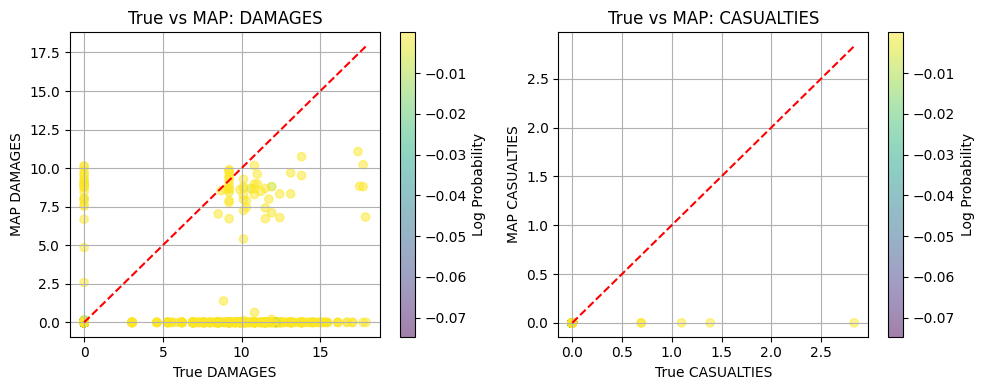

In [35]:
y_true, y_map, log_probs = run_inference_map(
    flow, test_loader, y_scaler, TARGET_COLS,
    n_iterations=100,  # gradient ascent steps per initialization
    lr=0.01,           # learning rate
    n_init_points=10   # number of random initializations
)

In [36]:
def visualize_single_training_example(flow, X_train, Y_train, idx, z_fixed, y_scaler, target_cols):
    """
    For one training example:
    - show its location in original 2D (damages, casualties)
    - show its latent z
    - show lattice in z and where that lattice maps in y (original space),
      all conditioned on the same context x[idx].
    """
    device = next(flow.parameters()).device

    # 1. Pick one training example (context + target) in standardized/log space
    x0 = X_train[idx:idx+1].to(device)   # [1, X_DIM]
    y0 = Y_train[idx:idx+1].to(device)   # [1, 2]

    with torch.no_grad():
        dist0 = flow(x0)                 # conditional p(y|x0)

        # 2. Map this y0 to latent space z0: y -> z
        z0 = dist0.transform.inv(y0)     # [1, 2]

        # 3. Map the lattice from latent space to y-space: z_lattice -> y_lattice
        z_latent = z_fixed.to(device)    # [N, 2]
        y_lattice = dist0.transform(z_latent)  # [N, 2]

    # 4. Undo scaling/log to get back to original damages/casualties
    y0_np = y0.cpu().numpy()
    y0_unscaled = np.expm1(y_scaler.inverse_transform(y0_np))[0]      # (2,)

    y_lattice_np = y_lattice.cpu().numpy()
    y_lattice_unscaled = np.expm1(y_scaler.inverse_transform(y_lattice_np))  # (N, 2)

    # 5. Prepare latent arrays for plotting
    z0_np = z0.cpu().numpy()[0]          # (2,)
    z_latent_np = z_latent.cpu().numpy() # (N, 2)

    # 6. Plots
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    # Left: original 2D target space (DAMAGES, CASUALTIES)
    ax = axes[0]
    ax.scatter(
        y_lattice_unscaled[:, 0], y_lattice_unscaled[:, 1],
        c=point_colors, s=40, alpha=0.7, edgecolors="k", linewidth=0.3,
        label="Lattice mapped to y"
    )
    ax.scatter(
        y0_unscaled[0], y0_unscaled[1],
        color="red", s=80, marker="x", label="Training example"
    )

    # Set limits to include both lattice and point, with a small margin
    xs = np.concatenate([y_lattice_unscaled[:,0], [y0_unscaled[0]]])
    ys = np.concatenate([y_lattice_unscaled[:,1], [y0_unscaled[1]]])
    x_min, x_max = xs.min(), xs.max()
    y_min, y_max = ys.min(), ys.max()
    margin_x = 0.05 * (x_max - x_min + 1e-6)
    margin_y = 0.05 * (y_max - y_min + 1e-6)
    ax.set_xlim(x_min - margin_x, x_max + margin_x)
    ax.set_ylim(y_min - margin_y, y_max + margin_y)

    ax.set_xlabel(target_cols[0])
    ax.set_ylabel(target_cols[1])
    ax.set_title("Original space (y) conditioned on x[idx]")
    ax.legend()
    ax.grid(True, alpha=0.3)

    # Right: latent space z
    ax = axes[1]
    ax.scatter(
        z_latent_np[:, 0], z_latent_np[:, 1],
        c=point_colors, s=40, alpha=0.7, edgecolors="k", linewidth=0.3,
        label="Lattice in z"
    )
    ax.scatter(
        z0_np[0], z0_np[1],
        color="red", s=60, marker="x", label="z of training y"
    )
    ax.set_xlabel("z1")
    ax.set_ylabel("z2")
    ax.set_title("Latent space (z) conditioned on x[idx]")
    ax.axhline(0, color="k", linestyle="--", alpha=0.3)
    ax.axvline(0, color="k", linestyle="--", alpha=0.3)
    ax.legend()
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

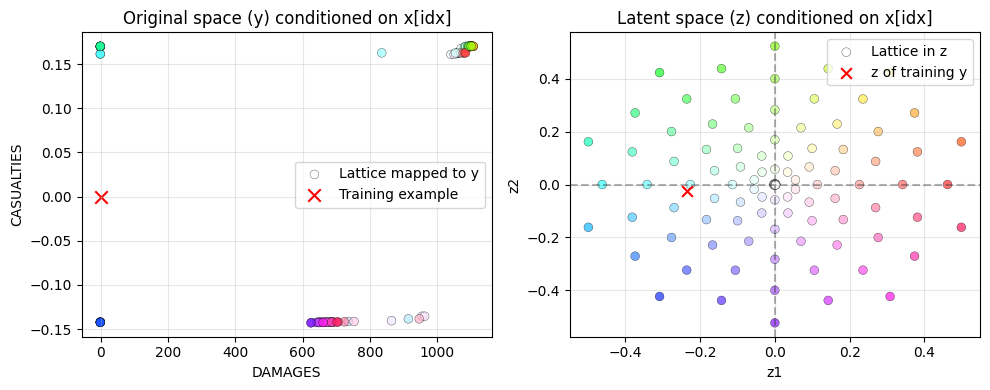

In [37]:
idx = 1  # or any training index
visualize_single_training_example(flow, X_train, Y_train, idx, z_fixed, y_scaler, TARGET_COLS)

## Result Analysis

In [38]:
X_test = X_test.to(device)
Y_test = Y_test.to(device)
pass

### Latent normality diagnostics


In [39]:
def collect_latents(flow, loader, device, max_samples=None):
    """Collect latent z samples for all (x, y) pairs in a DataLoader.

    Args:
        flow: Trained conditional flow model.
        loader: DataLoader yielding (x, y) batches in standardized space.
        device: Torch device.
        max_samples: Optional int, subsample to at most this many points.

    Returns:
        z: Tensor of shape (N, D) on CPU.
    """
    flow.eval()
    zs = []
    with torch.no_grad():
        for x_batch, y_batch in loader:
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)

            dist = flow(x_batch)
            # Forward transform: data space y -> latent space z
            z_batch = dist.transform(y_batch)

            zs.append(z_batch.cpu())

    z = torch.cat(zs, dim=0)

    if max_samples is not None and z.shape[0] > max_samples:
        idx = torch.randperm(z.shape[0])[:max_samples]
        z = z[idx]

    return z


In [40]:
def test_multivariate_normality(z_samples, label=""):
    """KS test of squared L2 norms vs Chi-square(D).

    z_samples: (N, D) tensor on any device.
    """
    D = z_samples.shape[1]
    squared_norms = (z_samples ** 2).sum(dim=1).cpu().numpy()

    ks_stat, p_value = stats.kstest(squared_norms, "chi2", args=(D,))

    prefix = f"[{label}] " if label else ""
    print(f"{prefix}Chi-Squared Fit: KS-Stat={ks_stat:.4f}, p-value={p_value:.4e}")
    if p_value < 0.05:
        print(f"{prefix}>> REJECT: The joint distribution is statistically NOT Standard Normal.")
    else:
        print(f"{prefix}>> ACCEPT: The joint distribution looks Standard Normal.")


def test_dimension_wise(z_samples, label=""):
    """Dimension-wise KS and Jarque–Bera tests vs standard normal.

    Prints per-dimension KS and JB p-values and a count of KS failures.
    """
    N, D = z_samples.shape
    prefix = f"[{label}] " if label else ""

    print(f"{prefix}Checking dimensions (N={N}, D={D})...")
    failures = 0
    for i in range(D):
        data = z_samples[:, i].cpu().numpy()

        # KS test vs standard normal
        ks_stat, ks_p = stats.kstest(data, "norm")

        # Jarque–Bera test (skewness & kurtosis)
        jb_stat, jb_p = stats.jarque_bera(data)

        if ks_p < 0.05:
            failures += 1

        print(
            f"{prefix}Dim {i}: KS p={ks_p:.3e}, JB p={jb_p:.3e} "
            f"(KS-stat={ks_stat:.3f}, JB-stat={jb_stat:.3f})"
        )

    print(f"{prefix}Dimensions failing KS normality (p < 0.05): {failures}/{D}")


In [41]:
# Collect latent samples for training and test sets

z_train = collect_latents(flow, train_loader, device, max_samples=50000)
z_test = collect_latents(flow, test_loader, device, max_samples=50000)

print(f"z_train shape: {z_train.shape}")
print(f"z_test shape:  {z_test.shape}")

print("\n=== Multivariate normality (Chi-square KS) ===")
test_multivariate_normality(z_train, label="train")
test_multivariate_normality(z_test, label="test")

print("\n=== Dimension-wise normality (KS + Jarque–Bera) ===")
test_dimension_wise(z_train, label="train")
test_dimension_wise(z_test, label="test")


z_train shape: torch.Size([40586, 2])
z_test shape:  torch.Size([8697, 2])

=== Multivariate normality (Chi-square KS) ===
[train] Chi-Squared Fit: KS-Stat=0.3430, p-value=0.0000e+00
[train] >> REJECT: The joint distribution is statistically NOT Standard Normal.
[test] Chi-Squared Fit: KS-Stat=0.3139, p-value=0.0000e+00
[test] >> REJECT: The joint distribution is statistically NOT Standard Normal.

=== Dimension-wise normality (KS + Jarque–Bera) ===
[train] Checking dimensions (N=40586, D=2)...
[train] Dim 0: KS p=0.000e+00, JB p=0.000e+00 (KS-stat=0.069, JB-stat=135846.750)
[train] Dim 1: KS p=0.000e+00, JB p=0.000e+00 (KS-stat=0.204, JB-stat=7955051520.000)
[train] Dimensions failing KS normality (p < 0.05): 2/2
[test] Checking dimensions (N=8697, D=2)...
[test] Dim 0: KS p=1.349e-25, JB p=0.000e+00 (KS-stat=0.058, JB-stat=21614.609)
[test] Dim 1: KS p=0.000e+00, JB p=0.000e+00 (KS-stat=0.198, JB-stat=3416033792.000)
[test] Dimensions failing KS normality (p < 0.05): 2/2


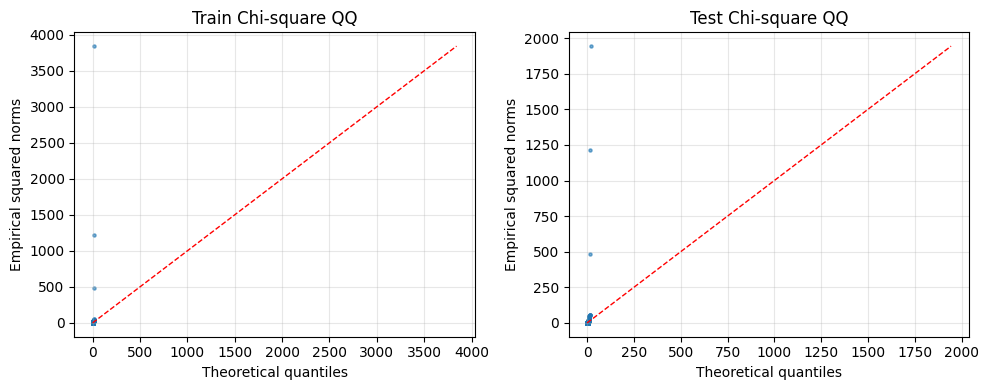

In [42]:
# Chi-squared QQ plots for joint normality

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, z, label in zip(axes, [z_train, z_test], ["Train", "Test"]):
    D = z.shape[1]
    r2 = (z ** 2).sum(dim=1).cpu().numpy()

    # Subsample for speed if very large
    max_points = 5000
    if r2.shape[0] > max_points:
        idx = np.random.choice(r2.shape[0], size=max_points, replace=False)
        r2 = r2[idx]

    r2_sorted = np.sort(r2)
    probs = (np.arange(1, len(r2_sorted) + 1) - 0.5) / len(r2_sorted)
    theo = stats.chi2.ppf(probs, df=D)

    ax.scatter(theo, r2_sorted, s=5, alpha=0.6)
    maxv = max(theo.max(), r2_sorted.max())
    ax.plot([0, maxv], [0, maxv], "r--", linewidth=1.0)
    ax.set_title(f"{label} Chi-square QQ")
    ax.set_xlabel("Theoretical quantiles")
    ax.set_ylabel("Empirical squared norms")
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


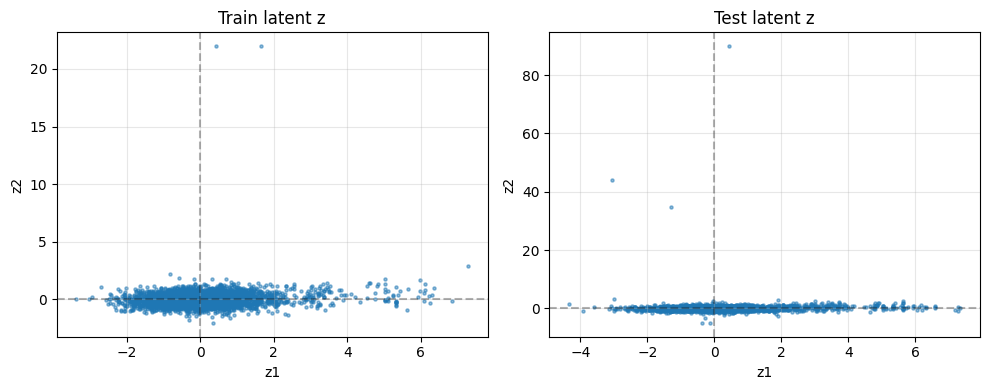

In [43]:
# 2D latent scatter plots for train and test

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

max_points = 5000

for ax, z, label in zip(axes, [z_train, z_test], ["Train", "Test"]):
    z_np = z.cpu().numpy()
    if z_np.shape[0] > max_points:
        idx = np.random.choice(z_np.shape[0], size=max_points, replace=False)
        z_np = z_np[idx]

    ax.scatter(z_np[:, 0], z_np[:, 1], s=5, alpha=0.5)
    ax.axhline(0, color="k", linestyle="--", alpha=0.3)
    ax.axvline(0, color="k", linestyle="--", alpha=0.3)
    ax.set_title(f"{label} latent z")
    ax.set_xlabel("z1")
    ax.set_ylabel("z2")
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


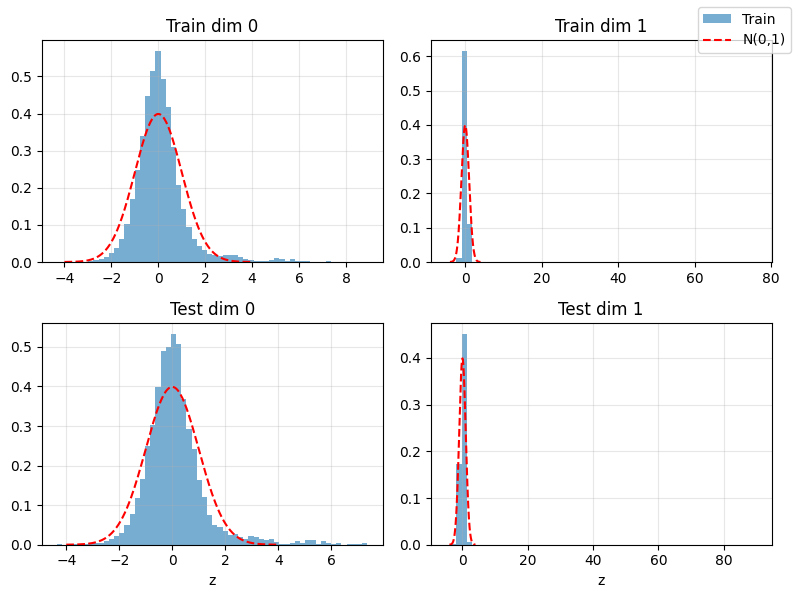

In [44]:
# Marginal histograms with standard normal PDF overlay

D = z_train.shape[1]
xs = np.linspace(-4, 4, 200)

fig, axes = plt.subplots(2, D, figsize=(4 * D, 6), sharex=False)

splits = [("Train", z_train), ("Test", z_test)]

for row, (label, z) in enumerate(splits):
    z_np = z.cpu().numpy()
    for col in range(D):
        ax = axes[row, col] if D > 1 else axes[row]
        data = z_np[:, col]
        ax.hist(data, bins=60, density=True, alpha=0.6, label=f"{label}")
        ax.plot(xs, stats.norm.pdf(xs), "r--", label="N(0,1)")
        ax.set_title(f"{label} dim {col}")
        if row == 1:
            ax.set_xlabel("z")
        ax.grid(True, alpha=0.3)

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper right")
plt.tight_layout()
plt.show()


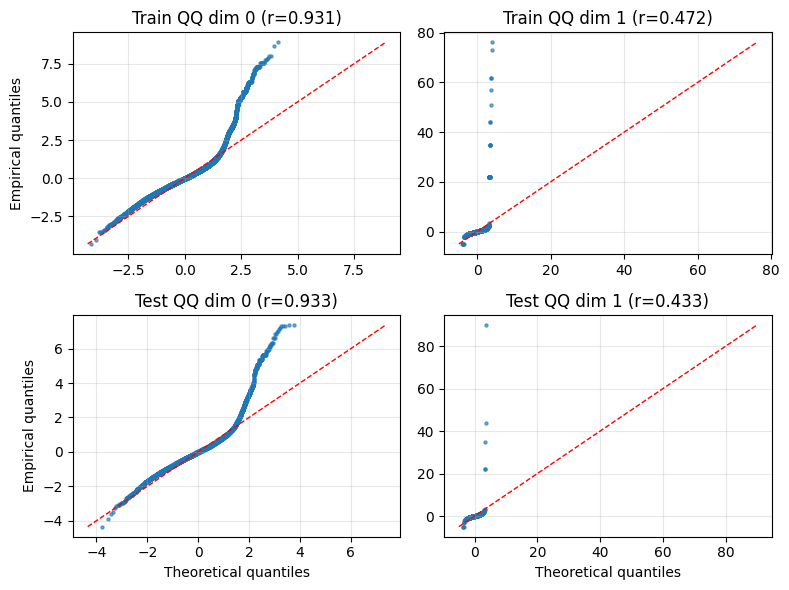

In [45]:
# Normal QQ plots per dimension and split

D = z_train.shape[1]
fig, axes = plt.subplots(2, D, figsize=(4 * D, 6))

splits = [("Train", z_train), ("Test", z_test)]

for row, (label, z) in enumerate(splits):
    z_np = z.cpu().numpy()
    for col in range(D):
        ax = axes[row, col] if D > 1 else axes[row]
        data = z_np[:, col]
        (osm, osr), (slope, intercept, r) = stats.probplot(data, dist="norm")
        ax.scatter(osm, osr, s=5, alpha=0.6)
        minv = min(osm.min(), osr.min())
        maxv = max(osm.max(), osr.max())
        ax.plot([minv, maxv], [minv, maxv], "r--", linewidth=1.0)
        ax.set_title(f"{label} QQ dim {col} (r={r:.3f})")
        if row == 1:
            ax.set_xlabel("Theoretical quantiles")
        if col == 0:
            ax.set_ylabel("Empirical quantiles")
        ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


Train correlation matrix:
 [[1.        0.0996734]
 [0.0996734 1.       ]]
Test correlation matrix:
 [[1.         0.05418642]
 [0.05418642 1.        ]]
Off-diagonal correlation (train): 0.09967339575048038
Off-diagonal correlation (test):  0.054186424123580886


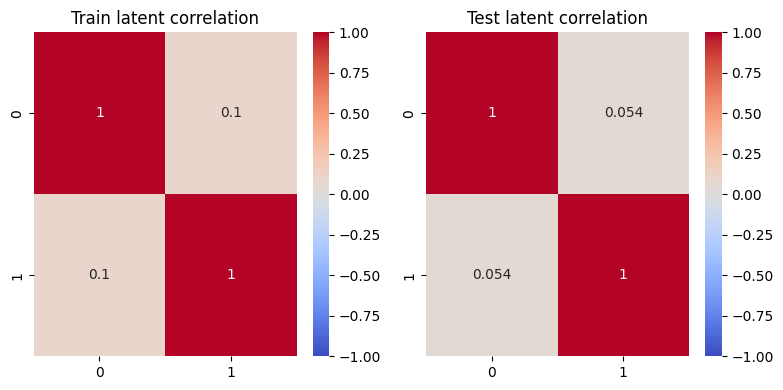

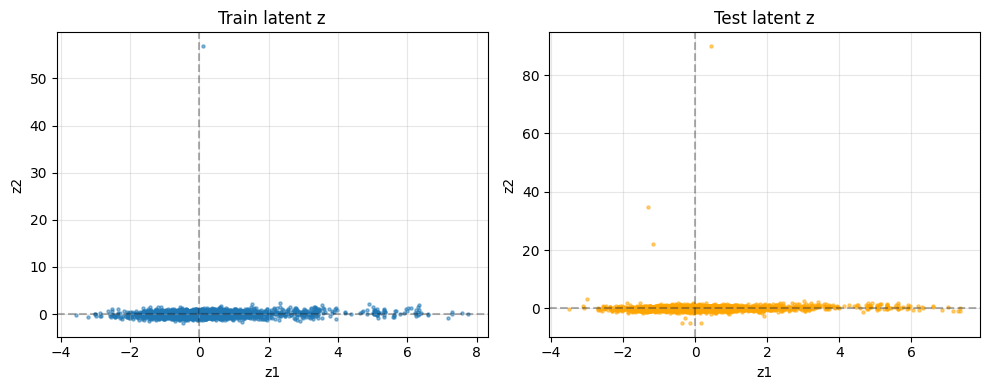


=== Latent normality summary ===
Train off-diagonal correlation should be near 0 if latents are independent.
Test off-diagonal correlation should also be near 0; larger magnitudes indicate residual dependence.


In [46]:
# Correlation matrices, heatmaps, and summary

z_train_np = z_train.cpu().numpy()
z_test_np = z_test.cpu().numpy()

corr_train = np.corrcoef(z_train_np.T)
corr_test = np.corrcoef(z_test_np.T)

print("Train correlation matrix:\n", corr_train)
print("Test correlation matrix:\n", corr_test)
print("Off-diagonal correlation (train):", corr_train[0, 1])
print("Off-diagonal correlation (test): ", corr_test[0, 1])

fig, axes = plt.subplots(1, 2, figsize=(8, 4))

sns.heatmap(corr_train, vmin=-1, vmax=1, annot=True, cmap="coolwarm", ax=axes[0])
axes[0].set_title("Train latent correlation")

sns.heatmap(corr_test, vmin=-1, vmax=1, annot=True, cmap="coolwarm", ax=axes[1])
axes[1].set_title("Test latent correlation")

plt.tight_layout()
plt.show()

# Scatter view with both splits
max_points = 5000

def _subsample(z_np, max_points=5000):
    if z_np.shape[0] > max_points:
        idx = np.random.choice(z_np.shape[0], size=max_points, replace=False)
        return z_np[idx]
    return z_np

zt_s = _subsample(z_train_np, max_points)
zs_s = _subsample(z_test_np, max_points)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.scatter(zt_s[:, 0], zt_s[:, 1], s=5, alpha=0.5, label="Train")
plt.axhline(0, color="k", linestyle="--", alpha=0.3)
plt.axvline(0, color="k", linestyle="--", alpha=0.3)
plt.title("Train latent z")
plt.xlabel("z1")
plt.ylabel("z2")
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.scatter(zs_s[:, 0], zs_s[:, 1], s=5, alpha=0.5, color="orange", label="Test")
plt.axhline(0, color="k", linestyle="--", alpha=0.3)
plt.axvline(0, color="k", linestyle="--", alpha=0.3)
plt.title("Test latent z")
plt.xlabel("z1")
plt.ylabel("z2")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n=== Latent normality summary ===")
print("Train off-diagonal correlation should be near 0 if latents are independent.")
print("Test off-diagonal correlation should also be near 0; larger magnitudes indicate residual dependence.")


#### 4. Partial Dependence Plot (Single Feature)

In [49]:
feats = [
    'BEGIN_LAT', 'BEGIN_LON',
    'DURATION_HOURS', 'HAIL_SIZE',
    'TIME_DAY_SIN', 'TIME_DAY_COS', 'TIME_YEAR_NORM',
    'PRECIPITATION', 'TMIN', 'TMAX',
    'ELEVATION', 'SLOPE',
    'COV_BARREN', 'COV_CULTIVATED', 'COV_VEGETATION',
    'COV_FOREST', 'COV_WATER', 'COV_SNOW_ICE', 'COV_URBAN',
    'RIVER_DISTANCE', 'SEA_DISTANCE'
]

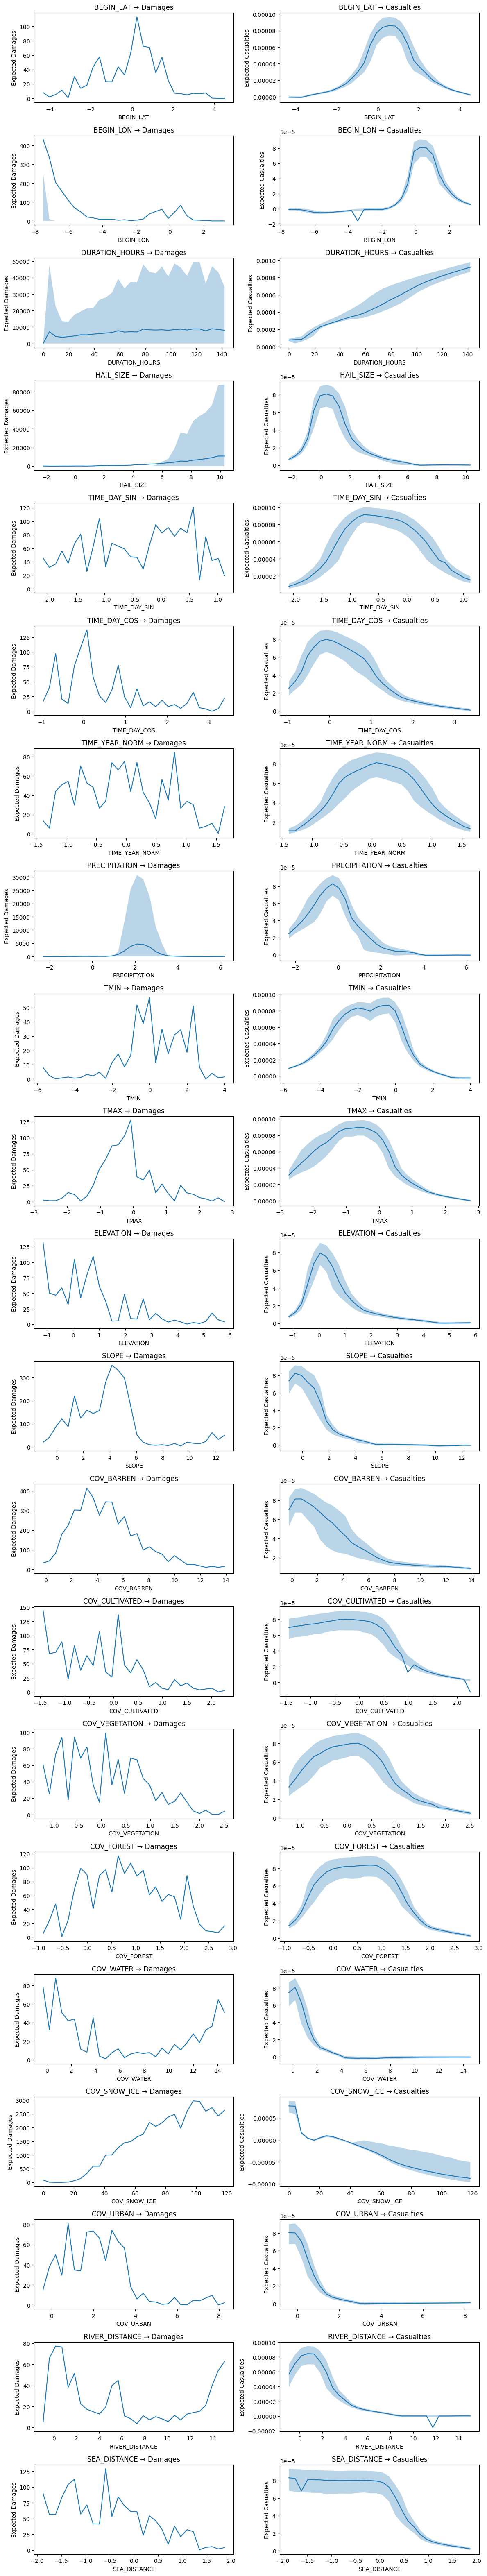

In [50]:
# Partial dependence for all features: damages and casualties, with uncertainty
n_feats = len(feats)
fig, axes = plt.subplots(n_feats, 2, figsize=(12, 3*n_feats), sharex=False)

for i, feature in enumerate(feats):
    k = X_COLS.index(feature)
    grid = np.linspace(X_train[:,k].min(), X_train[:,k].max(), 30)
    base = X_test.mean(0, keepdim=True)
    means_damages, q05_damages, q95_damages = [], [], []
    means_cas, q05_cas, q95_cas = [], [], []
    for g in grid:
        x = base.clone()
        x[0, k] = g
        s = sample_predictive(flow, x.to(next(flow.parameters()).device))
        means_damages.append(s[:,0].mean())
        q05_damages.append(np.percentile(s[:,0], 5))
        q95_damages.append(np.percentile(s[:,0], 95))
        means_cas.append(s[:,1].mean())
        q05_cas.append(np.percentile(s[:,1], 5))
        q95_cas.append(np.percentile(s[:,1], 95))
    # Damages
    ax = axes[i,0]
    ax.plot(grid, means_damages)
    ax.fill_between(grid, q05_damages, q95_damages, alpha=0.3)
    ax.set_ylabel("Expected Damages")
    ax.set_title(f"{feature} → Damages")
    # Casualties
    ax = axes[i,1]
    ax.plot(grid, means_cas)
    ax.fill_between(grid, q05_cas, q95_cas, alpha=0.3)
    ax.set_ylabel("Expected Casualties")
    ax.set_title(f"{feature} → Casualties")
    for a in axes[i]:
        a.set_xlabel(feature)
plt.tight_layout()
plt.show()


#### 5. ICE Curves (Heterogeneous Effects)

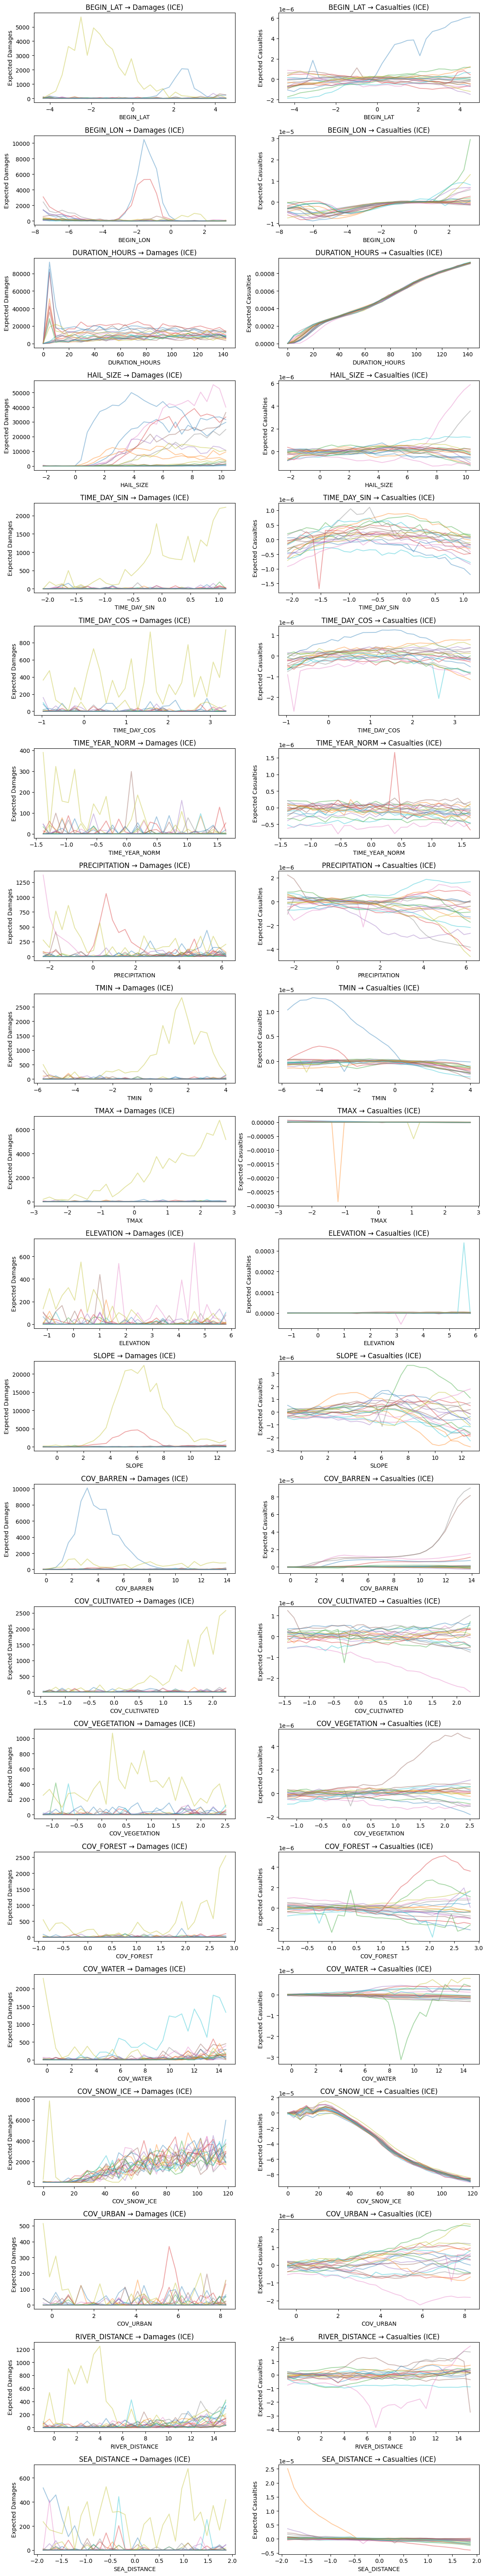

In [51]:
# ICE curves for all features: damages and casualties
n_feats = len(feats)
fig, axes = plt.subplots(n_feats, 2, figsize=(12, 3*n_feats), sharex=False)

n_ice = 20  # number of ICE curves per feature
for i, feature in enumerate(feats):
    k = X_COLS.index(feature)
    grid = np.linspace(X_train[:,k].min(), X_train[:,k].max(), 30)
    # Damages
    for j in range(n_ice):
        base = X_test[j:j+1].clone()
        curve_damages = []
        curve_cas = []
        for g in grid:
            x = base.clone()
            x[0, k] = g
            s = sample_predictive(flow, x.to(next(flow.parameters()).device), 500)
            curve_damages.append(s[:,0].mean())
            curve_cas.append(s[:,1].mean())
        axes[i,0].plot(grid, curve_damages, alpha=0.4)
        axes[i,1].plot(grid, curve_cas, alpha=0.4)
    axes[i,0].set_ylabel("Expected Damages")
    axes[i,0].set_title(f"{feature} → Damages (ICE)")
    axes[i,1].set_ylabel("Expected Casualties")
    axes[i,1].set_title(f"{feature} → Casualties (ICE)")
    for a in axes[i]:
        a.set_xlabel(feature)
plt.tight_layout()
plt.show()


#### 6. Counterfactual Location Comparison

In [52]:
x = X_test[10:11].clone()

urban_low = -2.0
urban_high = 2.0

x_low = x.clone()
x_high = x.clone()

x_low[0,k] = urban_low
x_high[0,k] = urban_high

s_low = sample_predictive(flow, x_low.to(next(flow.parameters()).device))
s_high = sample_predictive(flow, x_high.to(next(flow.parameters()).device))


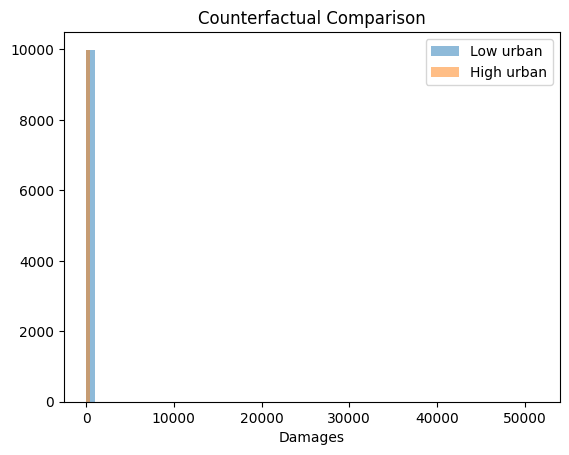

In [53]:
plt.hist(s_low[:,0], bins=50, alpha=0.5, label="Low urban")
plt.hist(s_high[:,0], bins=50, alpha=0.5, label="High urban")
plt.legend()
plt.xlabel("Damages")
plt.title("Counterfactual Comparison")
plt.show()


#### 7. Permutation Feature Importance

In [54]:
def permutation_importance(flow, X, Y, feature_index, n=500):
    idx = torch.randperm(len(X))[:n]
    Xp = X[idx].clone()
    Yp = Y[idx]

    with torch.no_grad():
        base = -flow(Xp).log_prob(Yp).mean().item()

    Xp[:,feature_index] = Xp[torch.randperm(len(Xp)),feature_index]

    with torch.no_grad():
        perm = -flow(Xp).log_prob(Yp).mean().item()

    return perm - base


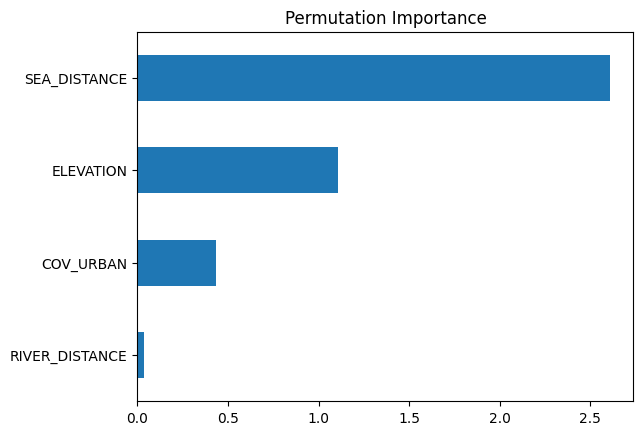

In [55]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
X_test = X_test.to(device)
Y_test = Y_test.to(device)

importances = {}

for f in ["COV_URBAN","ELEVATION","RIVER_DISTANCE","SEA_DISTANCE"]:
    k = X_COLS.index(f)
    importances[f] = permutation_importance(flow, X_test, Y_test, k)

pd.Series(importances).sort_values().plot.barh()
plt.title("Permutation Importance")
plt.show()


#### 8. Calibration / Coverage

In [56]:
def coverage(flow, X, Y, q=90):
    inside = []
    for i in range(200):
        x = X[i:i+1].to(next(flow.parameters()).device)
        s = sample_predictive(flow, x, 2000)
        lo = np.percentile(s, (100-q)/2, axis=0)
        hi = np.percentile(s, 100-(100-q)/2, axis=0)

        y = Y[i].cpu().numpy()
        y = np.expm1(y_scaler.inverse_transform(y.reshape(1,-1)))[0]

        inside.append(np.all((y>=lo)&(y<=hi)))
    return np.mean(inside)


In [57]:
print("90% interval coverage:", coverage(flow, X_test, Y_test))

90% interval coverage: 0.88
